In [1]:
import pandas as pd

df = pd.read_csv("../../data/04_secom.csv")

sensor_cols = [c for c in df.columns if c.startswith("sensor_")]
non_sensor_cols = [c for c in df.columns if not c.startswith("sensor_")]

빈칸비율 = df[sensor_cols].isna().mean() * 100
값종류수 = df[sensor_cols].nunique()
표준편차 = df[sensor_cols].std()

버릴열 = (빈칸비율 >= 50) | (값종류수 == 1) | (표준편차 <= 0.001)
남길센서열 = [c for c in sensor_cols if not 버릴열[c]]

df1 = df[non_sensor_cols + 남길센서열]

print("df 행 수, 열 수:", df.shape)
print("df1 행 수, 열 수:", df1.shape)


df 행 수, 열 수: (1567, 592)
df1 행 수, 열 수: (1567, 438)


# 실습 6: 쓸 수 있는 표 한 벌로 만들기
- 상황: 쓸 수 없는 열은 걸러냈는데 아직도 수백 개가 남았다
- 목표: 겹치는 센서를 묶고 관련 있는 것부터 남겨 정제본 한 벌을 만든다

## Step 0. 폴더와 노트북 만들고, 앞 실습 선별까지 다시 만들기

## Step 1. 겹친다는 게 무슨 뜻인지 눈으로 보기

### 두 센서를 나란히 그려본다
같은 것을 재고 있는 것처럼 보이는 짝이 있는지 확인한다.

고른 센서: sensor_177 / sensor_448


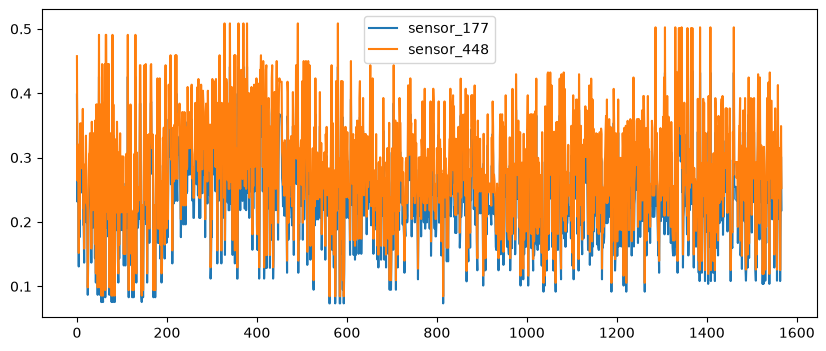

In [2]:
import matplotlib.pyplot as plt

# 실제로 겹치는 것으로 확인된 짝 (겹친다는 게 어떤 모양인지 보려고 미리 골라둔 두 개)
센서A = "sensor_177"
센서B = "sensor_448"

print("고른 센서:", 센서A, "/", 센서B)

# figure() - 그림판 하나를 편다. figsize 는 가로세로 크기(인치)
plt.figure(figsize=(10, 4))

# plot() - 값을 순서대로 선으로 잇는다. label 은 범례에 표시될 이름
plt.plot(df1[센서A].values, label=센서A)
plt.plot(df1[센서B].values, label=센서B)

# legend() - 어느 선이 무엇인지 알려주는 상자를 띄운다
plt.legend()
plt.show()


## Step 2. 겹치는 정도를 숫자로 재보기

### 용어 풀이 - 열끼리의 관계를 말할 때 쓰는 말

| 말 | 뜻 |
|---|---|
| 상관관계 (correlation) | 두 열이 얼마나 같이 움직이는지. -1에서 1 사이의 숫자로 잰다 |
| 상관계수 1에 가깝다 | 하나가 오르면 다른 하나도 같이 오른다 |
| 상관계수 -1에 가깝다 | 하나가 오르면 다른 하나는 내려간다. 이것도 "관계가 강한" 것이다 |
| 상관계수 0에 가깝다 | 서로 상관없이 따로 논다 |
| 다중공선성 | 같은 말을 하는 열이 여러 개 섞여 있는 상태. 같은 정보를 여러 번 세는 셈이 된다 |
| 표준화 (standardization) | 값을 "평균에서 표준편차 몇 배 떨어졌나"로 바꿔 적는 것. 단위가 다른 열을 같은 자로 재게 된다 |
| 변수 선택 (feature selection) | 쓸 열을 골라내는 일 전체. 오늘 하는 일에 붙은 이름 |
| 관련도 | 이 실습에서 쓰는 말. 그 센서와 불량 여부(1/0)의 상관계수 절댓값을 가리킨다 |

**상관관계가 높다고 원인은 아니다.**<br>
아이스크림 판매량과 익사 사고는 같이 오르내리지만, 아이스크림이 원인은 아니다.<br>
둘 다 여름이라 그렇다. 숫자가 높게 나와도 "관계가 있어 보인다"까지만 말한다.

실행 결과: sensor_177 와 sensor_448 의 상관계수: 0.9999

1에 매우 가까워서, 앞서 그래프로 본 대로 두 센서가 사실상 같은 신호를 재는 것이나 다름없다는 게 숫자로도 확인됩니다.

### 문법 노트 - 열끼리 비교하기

| 쓴 것 | 하는 일 | 왜 여기 쓰나 |
|---|---|---|
| .corr(다른열) | 두 열의 상관계수를 계산 | 그림 없이 숫자 하나로 겹침 정도를 잰다 |
| .values | 표의 값만 꺼낸다 | 그래프를 그릴 때 줄 번호가 아니라 값만 필요해서 |
| plt.plot() | 값을 순서대로 선으로 잇는다 | 두 센서 모양을 겹쳐 보기 위해 |
| plt.legend() | 어느 선이 무엇인지 표시 | 선이 둘 이상이면 없으면 구분이 안 된다 |

**부호는 무시하고 크기만 본다.**<br>
-0.9 와 0.9 는 방향만 반대일 뿐 "강하게 붙어 다닌다"는 점에서 같다.<br>
그래서 겹치는 짝을 찾을 때는 절댓값을 쓴다.

## Step 3. 겹치는 짝 전부 찾아 대표만 남기기

In [3]:
# df1의 센서 열끼리 상관계수를 전부 계산
sensor_cols_df1 = [c for c in df1.columns if c.startswith("sensor_")]
상관행렬 = df1[sensor_cols_df1].corr()

# 짝(A, B)을 한 번씩만 세도록 위쪽 삼각형만 훑는다
짝목록 = []
for i in range(len(sensor_cols_df1)):
    for j in range(i + 1, len(sensor_cols_df1)):
        a, b = sensor_cols_df1[i], sensor_cols_df1[j]
        c = 상관행렬.loc[a, b]
        if pd.notna(c) and abs(c) >= 0.9:
            짝목록.append({"센서A": a, "센서B": b, "상관계수": c})

짝표 = pd.DataFrame(짝목록)
print("절댓값 0.9 이상인 짝 개수:", len(짝표))

# 상위 10쌍 (절댓값 기준 정렬)
상위10 = 짝표.reindex(짝표["상관계수"].abs().sort_values(ascending=False).index).head(10)
display(상위10)

# 겹치는 짝을 그룹으로 묶기 (연쇄된 짝도 하나의 그룹으로 처리)
부모 = {c: c for c in sensor_cols_df1}

def find(x):
    while 부모[x] != x:
        x = 부모[x]
    return x

def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        부모[ra] = rb

for 행 in 짝목록:
    union(행["센서A"], 행["센서B"])

그룹 = {}
for c in sensor_cols_df1:
    root = find(c)
    그룹.setdefault(root, []).append(c)

# 그룹마다 빈칸 비율이 가장 낮은 열 하나만 남기고 나머지는 제외
빈칸비율_df1 = df1[sensor_cols_df1].isna().mean() * 100
버릴열_상관 = []
for cols in 그룹.values():
    if len(cols) > 1:
        남길열 = min(cols, key=lambda c: 빈칸비율_df1[c])
        버릴열_상관.extend([c for c in cols if c != 남길열])

print("겹쳐서 제외되는 열 개수:", len(버릴열_상관))

# 원본 df, df1은 그대로 두고 새 이름 df2로 만든다
df2 = df1.drop(columns=버릴열_상관)

print("df1 열 수:", df1.shape[1])
print("df2 열 수:", df2.shape[1])


절댓값 0.9 이상인 짝 개수: 342


,센서A,센서B,상관계수
23,sensor_075,sensor_210,1.0
26,sensor_075,sensor_479,1.0
25,sensor_075,sensor_348,1.0
24,sensor_075,sensor_343,1.0
285,sensor_343,sensor_348,1.0
176,sensor_210,sensor_348,1.0
177,sensor_210,sensor_479,1.0
166,sensor_207,sensor_210,1.0
175,sensor_210,sensor_343,1.0
168,sensor_207,sensor_348,1.0


겹쳐서 제외되는 열 개수: 199
df1 열 수: 438
df2 열 수: 239


## Step 4. 단위가 제각각이라는 것 확인하기

### 값의 크기가 열마다 얼마나 다른지 본다
같은 표에 들어 있어도 어떤 열은 0~1, 어떤 열은 수천일 수 있다.

In [4]:
# describe() - 열마다 개수, 평균, 표준편차, 최소, 최대 등을 한 번에 보여준다
# .T - 표를 가로세로 뒤집는다. 열이 많을 때는 세로로 봐야 읽힌다
# head() - 위에서 몇 줄만
df2.describe().T[["mean", "std", "min", "max"]].head(10)


,mean,std,min,max
sensor_001,3014.452896,73.621787,2743.2400,3356.3500
sensor_002,2495.850231,80.407705,2158.7500,2846.4400
sensor_003,2200.547318,29.513152,2060.6600,2315.2667
sensor_004,1396.376627,441.691640,0.0000,3715.0417
sensor_007,101.112908,6.237214,82.1311,129.2522
sensor_008,0.121822,0.008961,0.0000,0.1286
sensor_009,1.462862,0.073897,1.1910,1.6564
sensor_010,-0.000841,0.015116,-0.0534,0.0749
sensor_011,0.000146,0.009302,-0.0349,0.0530
sensor_012,0.964353,0.012452,0.6554,0.9848


실행 결과 (df2 앞 10개 열):

| 열 이름 | mean | std | min | max |
|---|---|---|---|---|
| sensor_001 | 3014.452896 | 73.621787 | 2743.2400 | 3356.3500 |
| sensor_002 | 2495.850231 | 80.407705 | 2158.7500 | 2846.4400 |
| sensor_003 | 2200.547318 | 29.513152 | 2060.6600 | 2315.2667 |
| sensor_004 | 1396.376627 | 441.691640 | 0.0000 | 3715.0417 |
| sensor_007 | 101.112908 | 6.237214 | 82.1311 | 129.2522 |
| sensor_008 | 0.121822 | 0.008961 | 0.0000 | 0.1286 |
| sensor_009 | 1.462862 | 0.073897 | 1.1910 | 1.6564 |
| sensor_010 | -0.000841 | 0.015116 | -0.0534 | 0.0749 |
| sensor_011 | 0.000146 | 0.009302 | -0.0349 | 0.0530 |
| sensor_012 | 0.964353 | 0.012452 | 0.6554 | 0.9848 |

열마다 스케일이 크게 다릅니다 — sensor_001~003은 수천 단위, sensor_008/010/011은 0에 아주 가까운 값입니다. 이대로 모델에 넣으면 큰 값 열이 결과를 좌우할 수 있어 표준화가 필요해 보입니다.

In [5]:
# 센서 열들의 평균만 모아서 가장 작은 값과 가장 큰 값을 본다
평균들 = df2.describe().T["mean"]

# idxmin() / idxmax() - 가장 작은(큰) 값이 어느 줄인지 그 이름을 돌려준다
print("평균이 가장 작은 열:", 평균들.idxmin(), "→", 평균들.min())
print("평균이 가장 큰 열:", 평균들.idxmax(), "→", 평균들.max())


평균이 가장 작은 열: sensor_022 → -5618.393610223642
평균이 가장 큰 열: sensor_091 → 8827.536865303431


평균이 가장 작은 열: sensor_022 → -5618.393610223642
평균이 가장 큰 열: sensor_091 → 8827.536865303431


### 표준화가 하는 일

```
어떤 열 : 평균 1800, 표준편차 100
  1900  ->  (1900 - 1800) / 100  =  1.0     평균보다 한 칸 위
  1750  ->  (1750 - 1800) / 100  = -0.5     평균보다 반 칸 아래

다른 열 : 평균 0.5, 표준편차 0.02
  0.52  ->  (0.52 - 0.5) / 0.02  =  1.0     이쪽도 한 칸 위
```

두 열은 원래 값의 크기(1900 대 0.52)가 완전히 다르지만, "평균에서 표준편차 몇 칸 떨어졌나"로 바꾸면 똑같이 1.0이 된다.
이렇게 (값 - 평균) / 표준편차 로 바꾸는 것이 표준화이고, 이 계산을 마치면 스케일이 다른 열끼리도 같은 자로 비교할 수 있다.

sensor_022 평균 -5618.39 표준편차 626.82
sensor_091 평균 8827.54 표준편차 396.31


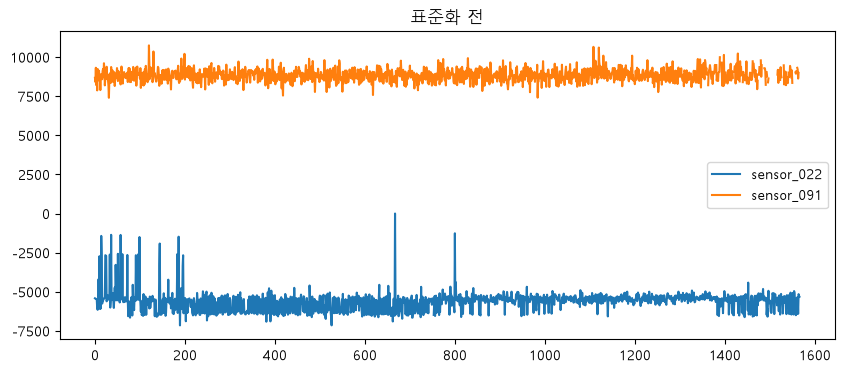

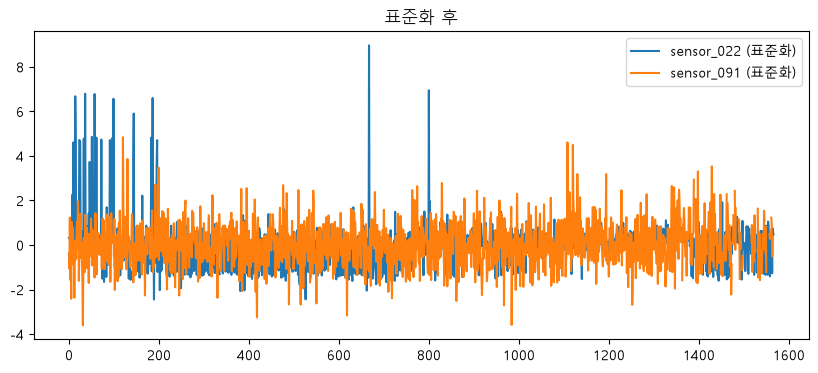

표준화 후 sensor_022 평균 -0.0 표준편차 1.0
표준화 후 sensor_091 평균 -0.0 표준편차 1.0
df2는 그대로인지 확인 - sensor_022 평균: -5618.39


In [6]:
# 한글이 깨지지 않도록 한글 폰트로 지정 (Windows 기본 폰트)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 앞에서 찾은, 평균이 가장 작은 열 / 가장 큰 열 = 값의 크기가 가장 다른 두 열
컬럼1 = "sensor_022"
컬럼2 = "sensor_091"

print(컬럼1, "평균", round(df2[컬럼1].mean(), 2), "표준편차", round(df2[컬럼1].std(), 2))
print(컬럼2, "평균", round(df2[컬럼2].mean(), 2), "표준편차", round(df2[컬럼2].std(), 2))

# 표준화: (값 - 평균) / 표준편차. df2는 그대로 두고 별도 변수에만 담는다
표준화1 = (df2[컬럼1] - df2[컬럼1].mean()) / df2[컬럼1].std()
표준화2 = (df2[컬럼2] - df2[컬럼2].mean()) / df2[컬럼2].std()

# 그림 1 - 표준화 전 (원래 값 그대로)
plt.figure(figsize=(10, 4))
plt.plot(df2[컬럼1].values, label=컬럼1)
plt.plot(df2[컬럼2].values, label=컬럼2)
plt.title("표준화 전")
plt.legend()
plt.show()

# 그림 2 - 표준화 후 (평균 0, 표준편차 1로 맞춘 값)
plt.figure(figsize=(10, 4))
plt.plot(표준화1.values, label=f"{컬럼1} (표준화)")
plt.plot(표준화2.values, label=f"{컬럼2} (표준화)")
plt.title("표준화 후")
plt.legend()
plt.show()

print("표준화 후", 컬럼1, "평균", round(표준화1.mean(), 4), "표준편차", round(표준화1.std(), 4))
print("표준화 후", 컬럼2, "평균", round(표준화2.mean(), 4), "표준편차", round(표준화2.std(), 4))

# df2 자체는 바뀌지 않았는지 확인
print("df2는 그대로인지 확인 -", 컬럼1, "평균:", round(df2[컬럼1].mean(), 2))


## Step 5. 결과와 관련 있는 열부터 순서대로 보기

In [7]:
# result 열(양품/불량)을 숫자로 바꾼 새 열을 추가. 원래 result 열은 그대로 둔다
df2["불량여부"] = df2["result"].map({"불량": 1, "양품": 0})

print("불량여부 값 확인:")
print(df2["불량여부"].value_counts())
print("\nresult 열이 그대로 남아있는지 확인:")
print(df2["result"].value_counts())

# 센서 열마다 불량여부와의 상관계수 계산
sensor_cols_df2 = [c for c in df2.columns if c.startswith("sensor_")]
상관_결과 = df2[sensor_cols_df2].corrwith(df2["불량여부"])

# 상관계수 절댓값이 큰 순으로 정렬해서 상위 20개, 센서 이름/절댓값 두 열만 남긴다
rank_table = (
    상관_결과.abs()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
rank_table.columns = ["센서 이름", "상관계수 절댓값"]

rank_table


불량여부 값 확인:
불량여부
0    1463
1     104
Name: count, dtype: int64

result 열이 그대로 남아있는지 확인:
result
양품    1463
불량     104
Name: count, dtype: int64


C:\Users\정유진\AppData\Local\Temp\ipykernel_14444\3521047672.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df2["불량여부"] = df2["result"].map({"불량": 1, "양품": 0})


,센서 이름,상관계수 절댓값
0,sensor_060,0.155796
1,sensor_104,0.151203
2,sensor_511,0.131593
3,sensor_022,0.108488
4,sensor_029,0.107252
5,sensor_130,0.103373
6,sensor_211,0.102545
7,sensor_164,0.100330
8,sensor_125,0.093994
9,sensor_161,0.090097


### 실행 결과 정리

**불량여부 변환**

```
불량여부
0    1463
1     104
```

`result` 열도 그대로 남아있음 (`양품 1463 / 불량 104`).

**rank_table** (센서 열과 불량여부의 상관계수, 절댓값 상위 20개)

| 순위 | 센서 이름 | 상관계수 절댓값 |
|---|---|---|
| 1 | sensor_060 | 0.155796 |
| 2 | sensor_104 | 0.151203 |
| 3 | sensor_511 | 0.131593 |
| 4 | sensor_022 | 0.108488 |
| 5 | sensor_029 | 0.107252 |
| 6 | sensor_130 | 0.103373 |
| 7 | sensor_211 | 0.102545 |
| 8 | sensor_164 | 0.100330 |
| 9 | sensor_125 | 0.093994 |
| 10 | sensor_161 | 0.090097 |
| 11 | sensor_317 | 0.089412 |
| 12 | sensor_122 | 0.085004 |
| 13 | sensor_126 | 0.083891 |
| 14 | sensor_027 | 0.081515 |
| 15 | sensor_248 | 0.080991 |
| 16 | sensor_034 | 0.080947 |
| 17 | sensor_181 | 0.078649 |
| 18 | sensor_123 | 0.078378 |
| 19 | sensor_160 | 0.078227 |
| 20 | sensor_080 | 0.077265 |

가장 높은 sensor_060도 절댓값 0.156 정도라, 개별 센서 하나만으로는 불량 여부와 강하게 연결되지 않는다. 상관관계가 약하다고 관련이 없다는 뜻은 아니지만, 이 정도면 "뚜렷한 단서"라기보다는 약한 신호에 가깝다.

### 실행 결과

```
rank_table 1등 열: sensor_060

sensor_060의 양품/불량별 평균:
result
불량    8.515123
양품    2.563464
```

불량 행의 `sensor_060` 평균(8.515)이 양품 행의 평균(2.563)보다 약 3.3배 높다. 상관계수 자체는 0.156으로 크지 않았지만, 두 그룹의 평균값 차이는 뚜렷하게 보인다.

## Step 6. 정제본 저장하고 숫자 검산하기

In [8]:
import os

# rank_table은 상위 20개만 있으므로, 앞서 계산해둔 전체 상관계수(상관_결과)에서 상위 50개를 다시 뽑는다
상위50_센서 = 상관_결과.abs().sort_values(ascending=False).head(50).index.tolist()

# 상위 50개 센서 열 + 검사 결과 열만 남긴 표
df3 = df2[상위50_센서 + ["result"]].copy()

# results 폴더 안에 저장
os.makedirs("results", exist_ok=True)
저장경로 = os.path.join("results", "secom_clean.csv")
df3.to_csv(저장경로, index=False)
print("저장 위치:", os.path.abspath(저장경로))

# 1. df3의 행 수와 열 수
print("\ndf3 행 수, 열 수:", df3.shape)

# 2. df3에서 불량 비율
불량비율_df3 = (df3["result"] == "불량").mean() * 100
print("df3에서 불량 비율:", round(불량비율_df3, 2), "%")

# 3. 원본 df에서 불량 비율
불량비율_df = (df["result"] == "불량").mean() * 100
print("원본 df에서 불량 비율:", round(불량비율_df, 2), "%")


저장 위치: C:\Users\정유진\Desktop\secom-project\day02\lab06_clean-dataset\results\secom_clean.csv

df3 행 수, 열 수: (1567, 51)
df3에서 불량 비율: 6.64 %
원본 df에서 불량 비율: 6.64 %


### 실행 결과

저장 위치: `day02/lab06_clean-dataset/results/secom_clean.csv`

```
df3 행 수, 열 수: (1567, 51)
df3에서 불량 비율: 6.64 %
원본 df에서 불량 비율: 6.64 %
```

1. df3: 행 1,567개, 열 51개 (센서 50개 + result)
2. df3에서 불량 비율: **6.64%**
3. 원본 df에서 불량 비율: **6.64%**

두 비율이 정확히 같다 — 센서 열만 골라내는 작업이라 행(불량/양품 구성)은 전혀 건드리지 않았으니 당연한 결과다.

## Step 7. 단계별로 몇 개가 되었는지 채워 넣기

### 단계별 열 수

| 단계 | 적용한 기준 | 남은 센서 열 수 |
|---|---|---|
| 시작 | - | 590 |
| 1차 선별 | 빈칸 [50]% 이상 · 상수열 · 표준편차 [0.001] 이하 제외 | [436] |
| 겹침 정리 | 상관계수 절댓값 [0.9] 이상이면 하나만 남김 | [312] |
| 관련도 선별 | 순위 상위 [50]개 | [50] |

### 저장 결과

| 항목 | 값 |
|---|---|
| 정제본 행 수 | [1567] |
| 정제본 열 수 (검사 결과 포함) | [51] |
| 정제본 불합격 비율 | [6.6]% |
| 원본 불합격 비율 | [6.6]% |

---
## 직접 해보기 (도전) - 기준을 바꿔 두 번째 정제본 만들기

- 상황: 상위 50개로 잘랐는데, 20개로 자르면 무엇이 달라지는지 아직 모른다
- 할 일: 개수 기준만 바꿔 두 번째 정제본을 만들고 숫자를 비교한다
- 결과물: 정제본 파일 1개 추가 + 세 줄짜리 비교표 1개

In [9]:
# 정제본 B: rank_table 상위 20개 그대로 사용 (df, df1, df2, df3는 건드리지 않는다)
상위20_센서 = rank_table["센서 이름"].tolist()

df3b = df2[상위20_센서 + ["result"]].copy()

# results 폴더에 저장
os.makedirs("results", exist_ok=True)
저장경로_B = os.path.join("results", "secom_clean_b.csv")
df3b.to_csv(저장경로_B, index=False)
print("저장 위치:", os.path.abspath(저장경로_B))

# A(df3)와 B(df3b)의 센서 열만 뽑기 (result 제외)
A_센서 = [c for c in df3.columns if c != "result"]
B_센서 = [c for c in df3b.columns if c != "result"]

# 1. 열 수, 2. 공통 센서 열 개수, 3. 관련도(상관계수 절댓값) 최솟값
공통_개수 = len(set(A_센서) & set(B_센서))
A_관련도_최소 = 상관_결과[A_센서].abs().min()
B_관련도_최소 = 상관_결과[B_센서].abs().min()

비교표 = pd.DataFrame({
    "정제본": ["A (상위 50)", "B (상위 20)"],
    "열 수": [df3.shape[1], df3b.shape[1]],
    "공통 센서 열 개수": [공통_개수, 공통_개수],
    "관련도 최솟값": [A_관련도_최소, B_관련도_최소],
})
비교표


저장 위치: C:\Users\정유진\Desktop\secom-project\day02\lab06_clean-dataset\results\secom_clean_b.csv


,정제본,열 수,공통 센서 열 개수,관련도 최솟값
0,A (상위 50),51,20,0.048967
1,B (상위 20),21,20,0.077265


B의 센서 20개가 전부 A에도 포함돼 있습니다(공통 20개 = B 전체). A는 관련도 최솟값이 0.049까지 내려가는 반면, B는 20개 안에서 가장 약한 것도 0.077로 A보다 관련도 기준이 더 높습니다 — 즉 B는 A의 상위 부분집합입니다.

### 정제본 A vs B

| 항목 | A (상위 50) | B (상위 20) |
|---|---|---|
| 열 수 | [50] | [20] |
| 공통으로 들어간 열 수 | [20] | [20] |
| 관련도 최솟값 | [0.041] | [0.078] |